In [ ]:
from __future__ import print_function
import os

# Temporary workaround for Windows OpenMP duplicate runtime initialization in notebooks.
# Must be set before importing torch/torchvision/numpy-linked libraries.
os.environ.setdefault("KMP_DUPLICATE_LIB_OK", "TRUE")

import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
import torchvision
import torchvision.transforms as transforms
from torch.utils.data import DataLoader, random_split
from torchvision.datasets import ImageFolder
import random
import pickle

# Set random seed for reproducibility
torch.manual_seed(42)

In [ ]:
use_cuda = True
print("CUDA available:", torch.cuda.is_available())
device = torch.device("cuda" if (use_cuda and torch.cuda.is_available()) else "cpu")
print(f"Using device: {device}")

CUDA available: True
Using device: cuda


In [ ]:
transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
])

flip_target = lambda y: 1 - y

train_dataset = ImageFolder(root="butterfly_anomaly_image/train", transform=transform, target_transform=flip_target)
idx_to_class_train = {cls: 1 - idx for cls, idx in train_dataset.class_to_idx.items()}    
print("Classes:", train_dataset.classes)
print("Class->idx:", idx_to_class_train)
print("Total:", len(train_dataset))

val_dataset = ImageFolder(root="butterfly_anomaly_image/val", transform=transform, target_transform=flip_target)
idx_to_class_val = {cls: 1 - idx for cls, idx in val_dataset.class_to_idx.items()}
print("Classes:", val_dataset.classes)
print("Class->idx:", idx_to_class_val)
print("Total:", len(val_dataset))

test_dataset = ImageFolder(root="butterfly_anomaly_image/test", transform=transform, target_transform=flip_target)
idx_to_class_test = {cls: 1 - idx for cls, idx in test_dataset.class_to_idx.items()}
print("Classes:", test_dataset.classes)
print("Class->idx:", idx_to_class_test)
print("Total:", len(test_dataset))

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True, num_workers=0)
val_loader = DataLoader(val_dataset, batch_size=32, shuffle=False, num_workers=0)
test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False, num_workers=0)

Classes: ['hybrid', 'non-hybrid']
Class->idx: {'hybrid': 1, 'non-hybrid': 0}
Total: 3096
Classes: ['hybrid', 'non-hybrid']
Class->idx: {'hybrid': 1, 'non-hybrid': 0}
Total: 663
Classes: ['hybrid', 'non-hybrid']
Class->idx: {'hybrid': 1, 'non-hybrid': 0}
Total: 665


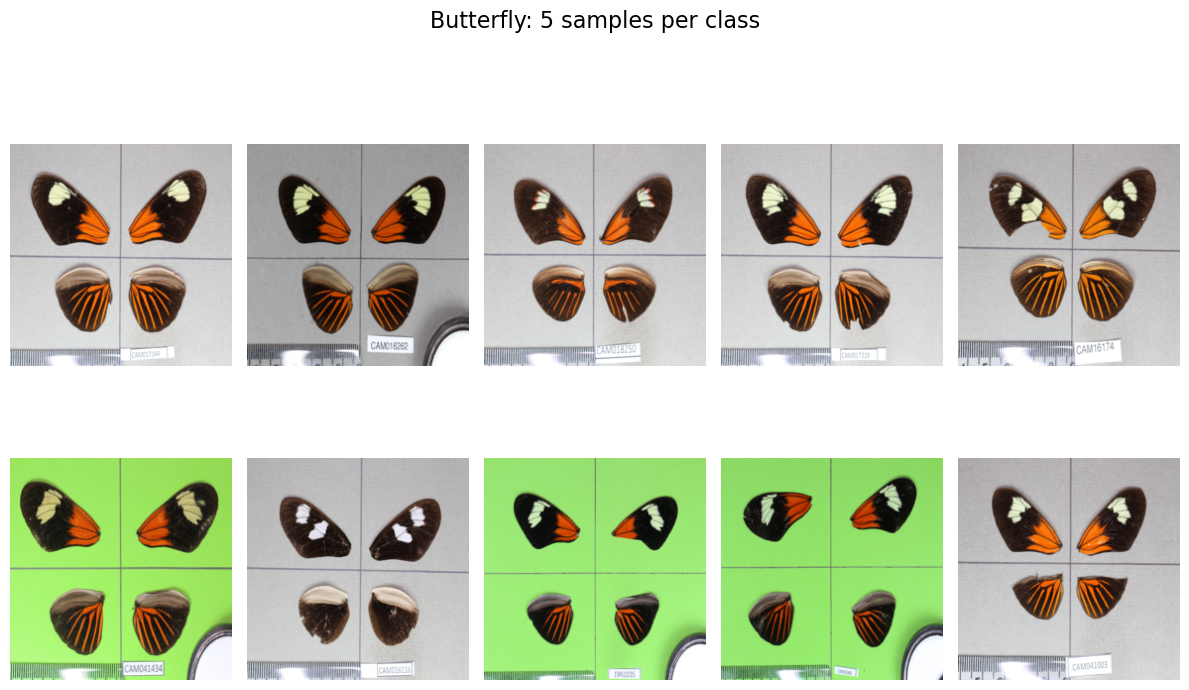

In [ ]:
num_classes = len(train_dataset.classes)
fig, axes = plt.subplots(num_classes, 5, figsize=(12, 4 * num_classes), squeeze=False)

# ImageFolder already stores labels in .targets
train_labels = train_dataset.targets

# idx -> class name mapping
idx_to_class = {idx: cls for cls, idx in train_dataset.class_to_idx.items()}

random.seed(42)
for c in range(num_classes):
    class_positions = [pos for pos, y in enumerate(train_labels) if y == c]
    picks = random.sample(class_positions, k=min(5, len(class_positions)))

    for j in range(5):
        ax = axes[c][j]
        ax.axis("off")

        if j < len(picks):
            img, label = train_dataset[picks[j]]
            ax.imshow(img.permute(1, 2, 0).numpy())
            if j == 0:
                ax.set_ylabel(idx_to_class[c], fontsize=11, rotation=0, labelpad=60, va="center")

plt.suptitle("Butterfly: 5 samples per class", fontsize=16)
plt.tight_layout()
plt.show()

In [ ]:
def conv3x3(in_channels, out_channels, stride=1):
    return nn.Conv2d(in_channels, out_channels, kernel_size=3,
                     stride=stride, padding=1, bias=False)

class ResidualBlock(nn.Module):
    def __init__(self, in_channels, out_channels, stride=1, downsample=None):
        super(ResidualBlock, self).__init__()
        
        self.conv1 = conv3x3(in_channels, out_channels, stride)
        self.bn1 = nn.BatchNorm2d(out_channels)
        self.relu = nn.ReLU()
        
        self.conv2 = conv3x3(out_channels, out_channels, stride=1)
        self.bn2 = nn.BatchNorm2d(out_channels)

        self.downsample = downsample

    def forward(self, x):
        residual = x
        
        out = self.relu(self.bn1(self.conv1(x)))
        
        out = self.bn2(self.conv2(out))

        if self.downsample:
            residual = self.downsample(x)
        
        out = self.relu(out + residual)
        return out

In [ ]:
class ResNet(nn.Module):
    def __init__(self, block, layers, num_classes=2):
        super(ResNet, self).__init__()
        self.in_channels = 16
        self.conv = conv3x3(3, 16)
        self.bn = nn.BatchNorm2d(16)
        self.relu = nn.ReLU(inplace=True)
        self.layer1 = self.make_layer(block, 16, layers[0])
        self.layer2 = self.make_layer(block, 32, layers[1], 2)
        self.layer3 = self.make_layer(block, 64, layers[2], 2)
        self.avg_pool = nn.AdaptiveAvgPool2d((1, 1))
        self.fc = nn.Linear(64, num_classes)

    def make_layer(self, block, out_channels, blocks, stride=1):
        downsample = None
        if (stride != 1) or (self.in_channels != out_channels):
            downsample = nn.Sequential(
                conv3x3(self.in_channels, out_channels, stride=stride),
                nn.BatchNorm2d(out_channels))
        layers = []
        layers.append(block(self.in_channels, out_channels, stride, downsample))
        self.in_channels = out_channels
        for i in range(1, blocks):
            layers.append(block(out_channels, out_channels))
        return nn.Sequential(*layers)

    def forward(self, x):
        out = self.conv(x)
        out = self.bn(out)
        out = self.relu(out)
        out = self.layer1(out)
        out = self.layer2(out)
        out = self.layer3(out)
        out = self.avg_pool(out)
        out = out.view(out.size(0), -1)
        out = self.fc(out)
        return out

    def save_checkpoint_append(
        self,
        ckpt_file,
        model,
        optimizer=None,
        epoch=None,
        train_loss=None,
        val_loss=None,
        f1_macro=None,
        f1_per_class=None
        ):
        os.makedirs(os.path.dirname(ckpt_file), exist_ok=True)

        record = {
            "epoch": epoch,
            "model_state_dict": model.state_dict(),
            "optimizer_state_dict": optimizer.state_dict() if optimizer is not None else None,
            "metrics": {
                "train_loss": train_loss,
                "val_loss": val_loss,
                "f1_macro": f1_macro,
                "f1_per_class": f1_per_class.tolist() if hasattr(f1_per_class, "tolist") else f1_per_class
            }
        }

        # Append new record to same file, do not delete old ones
        with open(ckpt_file, "ab") as f:
            pickle.dump(record, f)


    def load_checkpoint_latest(ckpt_file, model, optimizer=None, map_location=None):
        if not os.path.exists(ckpt_file):
            raise FileNotFoundError(f"Checkpoint file not found: {ckpt_file}")

        last_record = None
        with open(ckpt_file, "rb") as f:
            while True:
                try:
                    last_record = pickle.load(f)
                except EOFError:
                    break

        if last_record is None:
            raise ValueError("Checkpoint file is empty.")

        # Move tensors to desired device
        state_dict = {
            k: (v.to(map_location) if torch.is_tensor(v) and map_location is not None else v)
            for k, v in last_record["model_state_dict"].items()
        }
        model.load_state_dict(state_dict)

        if optimizer is not None and last_record.get("optimizer_state_dict") is not None:
            optimizer.load_state_dict(last_record["optimizer_state_dict"])

        return last_record["epoch"], last_record.get("metrics", {})


    def load_checkpoint_history(ckpt_file):
        history = []
        with open(ckpt_file, "rb") as f:
            while True:
                try:
                    history.append(pickle.load(f))
                except EOFError:
                    break
        return history

# Instantiate and verify
model = ResNet(ResidualBlock, [2, 2, 2]).to(device)

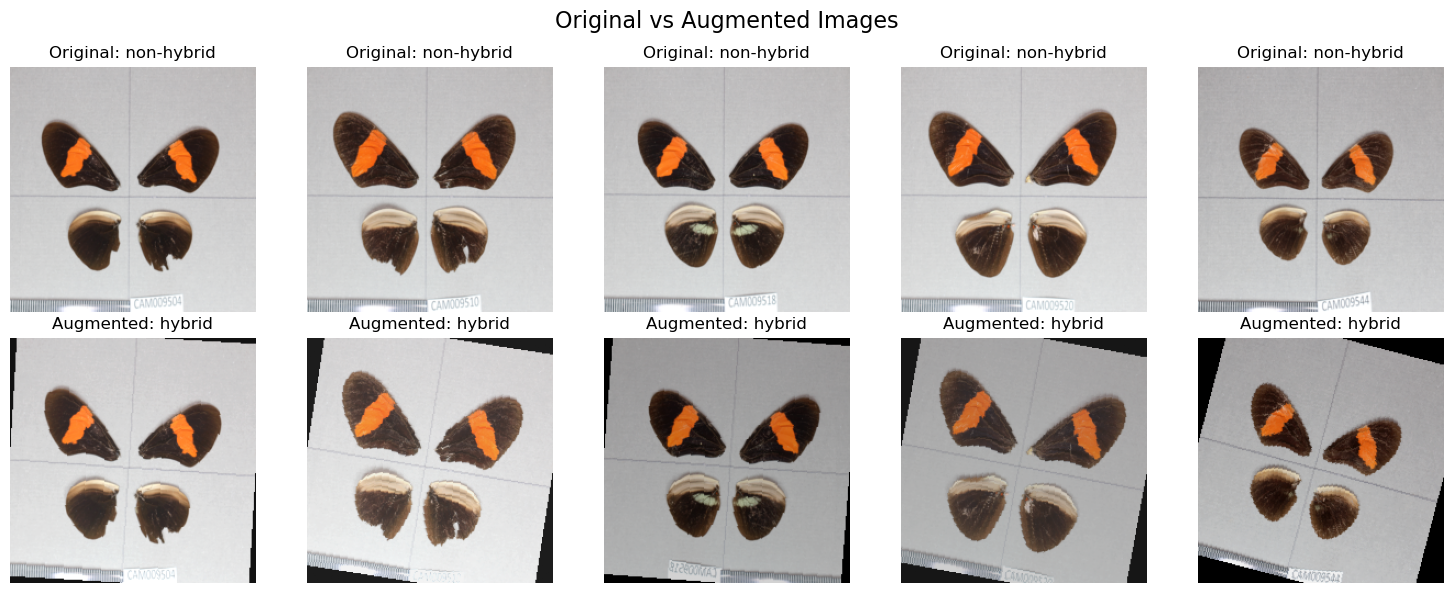

In [ ]:
transform_train = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(0.5),
    transforms.RandomRotation(15),
    transforms.ColorJitter(brightness=0.2, contrast=0.2),
    transforms.ToTensor(),
])

transform_eval = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
])

# Rebuild datasets from the SAME split folders, only changing transforms
train_dataset_aug = ImageFolder(root="butterfly_anomaly_image/train", transform=transform_train)
val_dataset = ImageFolder(root="butterfly_anomaly_image/val", transform=transform_eval)
test_dataset = ImageFolder(root="butterfly_anomaly_image/test", transform=transform_eval)

# Optional sanity check: class mapping must match across splits
assert train_dataset_aug.class_to_idx == val_dataset.class_to_idx == test_dataset.class_to_idx

# Display original vs augmented samples
class_names = train_dataset_aug.classes
fig, axes = plt.subplots(2, 5, figsize=(15, 6))

for i, ax in enumerate(axes[0]):
    img, label = train_dataset[i]  # original transform view
    ax.imshow(img.permute(1, 2, 0).numpy())
    ax.set_title(f"Original: {class_names[label]}")
    ax.axis("off")

for i, ax in enumerate(axes[1]):
    img, label = train_dataset_aug[i]  # augmented transform view
    img_np = img.permute(1, 2, 0).numpy().clip(0, 1)
    ax.imshow(img_np)
    ax.set_title(f"Augmented: {class_names[label]}")
    ax.axis("off")

plt.suptitle("Original vs Augmented Images", fontsize=16)
plt.tight_layout()
plt.show()

In [ ]:
from torchmetrics.classification import MulticlassF1Score

num_epochs = 30
batch_size = 32
learning_rate = 0.001

f1_macro_metric = MulticlassF1Score(num_classes=2, average="macro").to(device)
f1_per_class_metric = MulticlassF1Score(num_classes=2, average=None).to(device)

hybrid_idx = 1 - train_dataset.class_to_idx["hybrid"]

# Start with a moderate penalty boost, then tune (for example 2.0 to 5.0)
class_weights = torch.ones(len(train_dataset.classes), device=device)
class_weights[hybrid_idx] = 3.0

criterion = nn.CrossEntropyLoss(weight=class_weights)

def train_and_evaluate(model, train_set, val_set, optimizer, num_epochs):
    train_loader = DataLoader(train_set, batch_size = batch_size, shuffle=True)
    val_loader = DataLoader(val_set, batch_size = batch_size, shuffle=False)

    train_loss_list = []
    val_loss_list = []
    val_f1_macro_list = []
    val_f1_per_class_list = []

    for epoch in range(num_epochs):
        model.train()
        epoch_loss = 0

        for images, labels in train_loader:
            images, labels = images.to(device), labels.to(device)
            optimizer.zero_grad()
            outputs = model(images)

            loss = criterion(outputs, labels)
            loss.backward() 
            optimizer.step()

            epoch_loss += loss.item()

        avg_train_loss = epoch_loss / len(train_loader)
        train_loss_list.append(avg_train_loss)

        model.eval()
        val_loss = 0

        f1_macro_metric.reset()
        f1_per_class_metric.reset()

        with torch.no_grad():
            for images, labels in val_loader:
                images, labels = images.to(device), labels.to(device)
                outputs = model(images)
                loss = criterion(outputs, labels)
                val_loss += loss.item()
                _, predicted = torch.max(outputs, 1)
                f1_macro_metric.update(predicted, labels)
                f1_per_class_metric.update(predicted, labels)

        avg_val_loss = val_loss / len(val_loader)

        val_loss_list.append(avg_val_loss)
        val_f1_macro_list.append(f1_macro_metric.compute().item())
        val_f1_per_class_list.append(f1_per_class_metric.compute().cpu().numpy())

        model.save_checkpoint_append(
            ckpt_file="saved_models/model_a_log.pkl",
            model=model,
            optimizer=optimizer,
            epoch=epoch + 1,
            train_loss=avg_train_loss,
            val_loss=avg_val_loss,
            f1_macro=val_f1_macro_list[-1],
            f1_per_class=val_f1_per_class_list[-1]
        )

        if (epoch + 1) % 5 == 0:
            print(f"Epoch [{epoch+1}/{num_epochs}], "
                  f"Train Loss: {avg_train_loss:.4f}, "
                  f"Val Loss: {avg_val_loss:.4f}, "
                  f"Val F1-Macro: {val_f1_macro_list[-1]:.4f}, "
                  f"Val F1-Per-Class: {val_f1_per_class_list[-1]}")

    return train_loss_list, val_loss_list, val_f1_macro_list, val_f1_per_class_list

In [ ]:
# Model A: RESNET with augmentation
model_a = ResNet(ResidualBlock, [2, 2, 2], num_classes=2).to(device)
optimizer_a = optim.Adam(model_a.parameters(), lr=learning_rate)

print("\nTraining Model A (with augmentation)...")
results_a = train_and_evaluate(model_a, train_dataset_aug, val_dataset, optimizer_a, num_epochs)


Training Model A (with augmentation)...
Epoch [5/30], Train Loss: 0.1554, Val Loss: 0.3042, Val F1-Macro: 0.4552, Val F1-Per-Class: [0.        0.9104355]
Epoch [10/30], Train Loss: 0.1513, Val Loss: 0.3206, Val F1-Macro: 0.4552, Val F1-Per-Class: [0.        0.9104355]
